In [1]:
# 1. SETUP THE PACKAGES REQUIRED
%%capture
!pip install contextily

import pandas as pd
import geopandas as gpd
import requests
from shapely.geometry import Point
import folium
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import os
import zipfile
import matplotlib.font_manager as fm
import textwrap

In [12]:
# 2. PREPARE F1 CIRCUIT DATASET: List of Circuit Location as GeoDataFrame
## (Ref: https://github.com/bacinger/f1-circuits/blob/master/f1-locations.json)
## (Ref: https://en.wikipedia.org/wiki/2026_Formula_One_World_Championship)
data = [
    (1, "Albert Park Circuit", "Melbourne", -37.846, 144.970),
    (2, "Shanghai International Circuit", "Shanghai", 31.340, 121.221),
    (3, "Suzuka International Racing Course", "Suzuka", 34.844, 136.534),
    (4, "Miami International Autodrome", "Miami", 25.958, -80.239),
    (5, "Circuit Gilles-Villeneuve", "Montreal", 45.506, -73.525),
    (6, "Circuit de Monaco", "Monaco", 43.737, 7.429),
    (7, "Circuit de Barcelona-Catalunya", "Barcelona", 41.569, 2.259),
    (8, "Red Bull Ring", "Spielberg", 47.223, 14.761),
    (9, "Silverstone Circuit", "Silverstone", 52.072, -1.017),
    (10, "Circuit de Spa-Francorchamps", "Stavelot", 50.436, 5.971),
    (11, "Hungaroring", "Budapest", 47.583, 19.250),
    (12, "Circuit Zandvoort", "Zandvoort", 52.389, 4.541),
    (13, "Autodromo Nazionale Monza", "Monza", 45.621, 9.290),
    (14, "Circuito de Madring", "Madrid", 40.471, -3.620),
    (15, "Baku City Circuit", "Baku", 40.369, 49.842),
    (16, "Marina Bay Street Circuit", "Singapore", 1.291, 103.859),
    (17, "Circuit of the Americas", "Austin", 30.135, -97.633),
    (18, "Autódromo Hermanos Rodríguez", "Mexico City", 19.402, -99.091),
    (19, "Autódromo José Carlos Pace - Interlagos", "São Paulo", -23.702, -46.698),
    (20, "Las Vegas Street Circuit", "Las Vegas", 36.116, -115.168),
    (21, "Losail International Circuit", "Lusail", 25.490, 51.454),
    (22, "Yas Marina Circuit", "Abu Dhabi", 24.471, 54.601),
]
df = pd.DataFrame(data, columns=["round","name","city","lat","lon"])

## Convert Dataframe CRS to EPSG:3857 for Compatibility
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
    )
gdf = gdf.to_crs(epsg=3857)
gdf.head()

,round,name,city,lat,lon,geometry
0,1,Albert Park Circuit,Melbourne,-37.846,144.970,POINT (16137986.58 -4557693.562)
1,2,Shanghai International Circuit,Shanghai,31.340,121.221,POINT (13494259.993 3676983.783)
2,3,Suzuka International Racing Course,Suzuka,34.844,136.534,POINT (15198895.356 4142701.524)
3,4,Miami International Autodrome,Miami,25.958,-80.239,POINT (-8932164.622 2993879.993)
4,5,Circuit Gilles-Villeneuve,Montreal,45.506,-73.525,POINT (-8184765.561 5701535.712)


In [3]:
# 3. PREPARE F1 CIRCUIT DATASET: List of F1 Circuit Location as GeoJSON
## (Ref: https://github.com/bacinger/f1-circuits)
## Convert GeoJSON CRS to EPSG:3857 for Compatibility
url = "https://raw.githubusercontent.com/bacinger/f1-circuits/master/f1-circuits.geojson"
circuits = gpd.read_file(url).to_crs(epsg=3857)
circuits.head()

,id,Location,Name,opened,firstgp,length,altitude,geometry
0,au-1953,Melbourne,Albert Park Circuit,1953,1996,5278,10,"LINESTRING (16137835.631 -4558223.203, 1613772..."
1,bh-2002,Sakhir,Bahrain International Circuit,2002,2004,5412,-16,"LINESTRING (5622807.481 3003015.831, 5622817.9..."
2,cn-2004,Shanghai,Shanghai International Circuit,2004,2004,5451,14,"LINESTRING (13493968.336 3676571.277, 13493860..."
3,es-1991,Barcelona,Circuit de Barcelona-Catalunya,1991,1991,4655,165,"LINESTRING (251717.97 5096788.644, 251551.659 ..."
4,mc-1929,Monaco,Circuit de Monaco,1929,1929,3337,47,"LINESTRING (826791.12 5425202.519, 826788.894 ..."


In [4]:
# 4. STYLING SETUP: Hex Color and Font
## F1 Hex Color Code (Ref: https://www.brandcolorcode.com/formula-one)
F1_RED = '#FF1E00'
BG_BLACK = '#15151E'

## F1 font (Ref: https://fontforfree.com/formula-1-font/)
font_zip_path = 'F1-Font-Family.zip'
font_extract_path = 'F1-Font-Family'

## Create Font Directory, Extract Font Zipfile, and Find the Font File
if not os.path.exists(font_extract_path):
    os.makedirs(font_extract_path)
with zipfile.ZipFile(font_zip_path, 'r') as zip_ref:
    zip_ref.extractall(font_extract_path)
print(f"Font files extracted to: {font_extract_path}")

font_files = fm.findSystemFonts(fontpaths=font_extract_path)
f1_font_path = None
for font_file in font_files:
    if 'Formula1-Bold_web.ttf' in font_file: # <- Choose the preferred font here
        f1_font_path = font_file
        break
if f1_font_path:
    fm.fontManager.addfont(f1_font_path)
    f1_font_family = fm.FontProperties(fname=f1_font_path).get_name()
    print(f"F1 font '{f1_font_family}' registered from: {f1_font_path}")
else:
    f1_font_family = 'sans-serif'
    print(f"F1 font not found. Using '{f1_font_family}' as default font.")

Font files extracted to: F1-Font-Family
F1 font 'Formula1' registered from: /content/F1-Font-Family/Formula1-Bold_web.ttf


In [5]:
# 5. EXPLORE AND OVERLAY SPATIAL DATA USING FOLIUM
## Set the Map Layout
center_lat = df['lat'].mean()
center_lon = df['lon'].mean()
zoom_start = 3
m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, control_scale=True)

## Add the points from gdf to the map using folium.GeoJson
popup = folium.GeoJsonPopup(fields=["name"])
folium.GeoJson(gdf, name="F1 Circuits (Point)", popup=popup).add_to(m)

## Add the circuit track layouts to the map using folium.GeoJson
folium.GeoJson(circuits, name="Circuit Layouts (PolyLine)", style_function=lambda x: {"color": F1_RED, "weight": 3, "opacity": 1,"smooth_factor": 0,},).add_to(m)

folium.LayerControl().add_to(m)
m

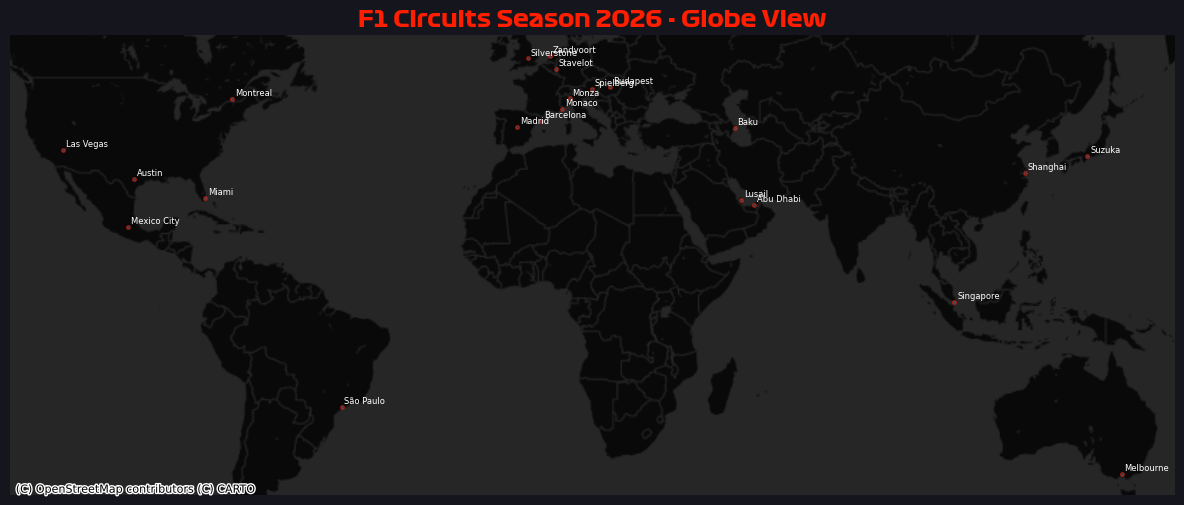

In [6]:
# 6. GLOBE MAP VISUALIZATION: Plot using Matplotlib
## Set the Plot Layout
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_BLACK)

## Add the gdf Dataset into the Plot
gdf.plot(ax=ax, edgecolor=F1_RED, linewidth=1.2, alpha=0.5, markersize=6)
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['city']):
    ax.annotate(label, xy=(x, y), xycoords='data', xytext=(2, 2), textcoords='offset points', fontsize=6, color='white')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels)
ax.set_title('F1 Circuits Season 2026 - Globe View', fontsize=16, fontfamily=f1_font_family, color=F1_RED)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [7]:
# 7. DEFINE FUNCTION: Zoom into individual circuits (high-res satellite imagery)
def plot_circuit(ax, lat, lon, name, buffer=2500):
    ## Convert the single circuit point to Web Mercator
    gdf_single = gpd.GeoDataFrame(
        {"name": [name]},
        geometry=[Point(lon, lat)],
        crs="EPSG:4326"
    ).to_crs(epsg=3857)
    x, y = gdf_single.geometry.x.iloc[0], gdf_single.geometry.y.iloc[0]

    ## Setup the Layout
    ax.set_xlim(x - buffer, x + buffer)
    ax.set_ylim(y - buffer, y + buffer)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, alpha=0.9)

    ## Format the Text Elements and Title Box in the Layout
    circuit_layout = circuits[circuits['Name'] == name]
    if not circuit_layout.empty:
        circuit_layout.plot(ax=ax, color=F1_RED, linewidth=1.5, alpha=1.0)
    if ' ' in name: ## Split the name into two lines if it contains a space
        first_space_idx = name.find(' ')
        formatted_name = name[:first_space_idx] + '\n' + name[first_space_idx+1:]
    else:
        formatted_name = name
    title_height_in_axes_coords = 0.1
    title_rect = plt.Rectangle((0, 1 - title_height_in_axes_coords), 1, title_height_in_axes_coords,
                               facecolor='black', edgecolor='none', transform=ax.transAxes)
    ax.add_patch(title_rect)
    ax.text(0.5, 1 - (title_height_in_axes_coords / 2), formatted_name,
            horizontalalignment='center', verticalalignment='center',
            fontsize=8, fontfamily=f1_font_family, color='white',
            transform=ax.transAxes)

    ax.set_axis_off()

In [8]:
# 8. SATELLITE VISUALIZATION: Plot Result (This takes some time to process)
nrows = 6
ncols = 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3))
axs = axs.flatten()

## Iterate plot for every circuit in gdf using plot_circuit function
for i, (index, row) in enumerate(df.iterrows()):
    if i < len(axs):
        ax = axs[i]
        plot_circuit(ax, row['lat'], row['lon'], row['name'])
    else:
        break

## Hide any remaining unused subplots
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout(pad=1)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

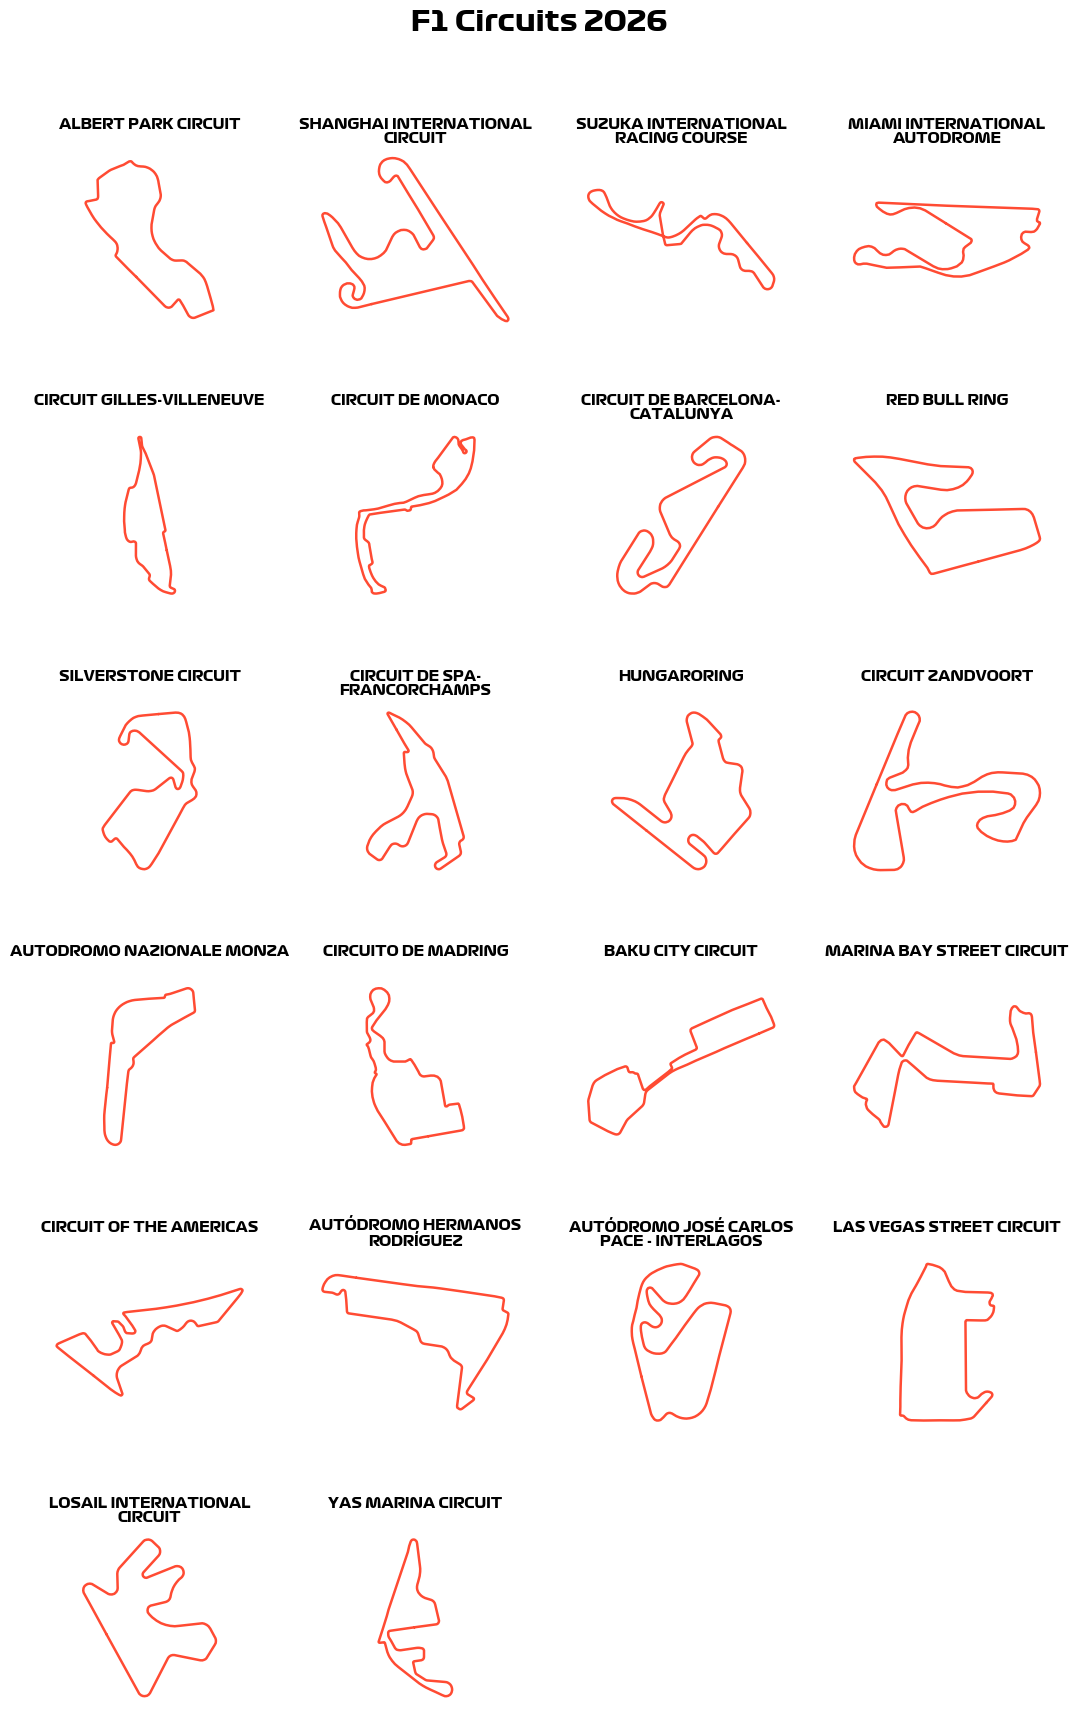

In [19]:
# 9. POSTER VISUALIZATION: Plot F1 Circuits GeoJSON using matplotlib
## Define TextWrap function to Adjust Title
def wrap_text(name, width, lines):
    wrapped = textwrap.wrap(name, width=width)
    while len(wrapped) < lines:
        wrapped.append("")
    return "\n".join(wrapped[:lines])

## Plot the Result
nrows = 6
cols = 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 3, nrows * 3))
axs = axs.flatten()

## Iterate for every circuit in df
for i, (idx, row) in enumerate(df.iterrows()):
    if i < len(axs):
        ax = axs[i]
        circuit_name = row['name']

        ## Find the corresponding geometry in the 'circuits' GeoDataFrame
        circuit_layout = circuits[circuits['Name'] == circuit_name]

        if not circuit_layout.empty:
            geom = circuit_layout.geometry.iloc[0]

            ## Split the circuit name into two lines using wrap_text
            formatted_circuit_name = wrap_text(circuit_name.upper(), width=25, lines=2)

            if geom.geom_type == 'LineString':
                x, y = geom.xy
                ax.plot(x, y, linewidth=1.8, alpha=0.8, color=F1_RED, solid_capstyle='round')
            elif geom.geom_type == 'MultiLineString':
                for line in geom.geoms:
                    x, y = line.xy
                    ax.plot(x, y, linewidth=1.8, alpha=0.8, color=BG_BLACK, solid_capstyle='round')
            ax.text(
                  0.5, 1.05,
                  formatted_circuit_name,
                  transform=ax.transAxes,
                  ha='center',
                  va='bottom',
                  fontsize=10,
                  fontfamily=f1_font_family,
                  linespacing=1.1
              )
            ax.set_aspect('equal', adjustable='datalim')
            ax.set_axis_off()
        else:
            break
    else:
        break

## Hide any remaining unused subplots
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle('F1 Circuits 2026', fontfamily=f1_font_family, fontsize=20)
plt.tight_layout(pad=5)
plt.subplots_adjust(hspace=0.6, wspace=0.3, top=0.9)
plt.show()